# 🛍️ User Behavior — Dự đoán Next Action với RNN / LSTM / biLSTM

## Bài toán
Dựa vào **chuỗi hành vi** của user, dự đoán **action tiếp theo** họ sẽ thực hiện (multiclass classification, 8 class).

| | |
|---|---|
| **Dữ liệu** | 500 users · 922 products · 7657 events · 8 loại action |
| **Task** | Multiclass: dự đoán next action trong chuỗi |
| **Label** | add_to_cart · checkout · click · comment · purchase · rating · remove_from_cart · view |
| **Input** | Chuỗi N action gần nhất + time_delta |
| **Split** | 70% train / 15% val / 15% test — **theo thời gian** |
| **Models** | RNN · LSTM · biLSTM |
| **Metrics** | Accuracy · F1-macro · F1-weighted · Loss |

> **Tại sao next-action thay vì binary purchase?**  
> Dataset có 922 products nhưng chỉ ~7.8 samples/product → next-product prediction quá thưa.  
> Binary purchase bị data leakage (token `purchase` nằm trong input sequence).  
> Next-action có 8 class, 7157 pairs, transition pattern rõ ràng, và có giá trị thực tế cho hệ thống recommend.

## 1. Import & Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, ConfusionMatrixDisplay
)
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Device : {device}')
print('✅ Import xong!')

Device : cuda
✅ Import xong!


## 2. Load & Tiền xử lý

In [2]:
df = pd.read_csv('/kaggle/input/datasets/lthynh/user-beahvioe/user_behavior (1).csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(['user_id', 'timestamp']).reset_index(drop=True)

# Encode action
le = LabelEncoder()
df['action_id'] = le.fit_transform(df['action']) + 1   # 0 = padding
NUM_CLASSES  = len(le.classes_)                         # 8
VOCAB_ACTION = NUM_CLASSES + 1                          # +1 cho padding

# Time delta (normalize 0-1, clip 1h)
df['time_delta'] = (
    df.groupby('user_id')['timestamp']
    .diff().dt.total_seconds().fillna(0)
    .clip(0, 3600) / 3600
)

# Tạo cặp (sequence, next_action_id)
# Label = action_id của event tiếp theo (0-indexed cho CrossEntropy)
df['next_action_id'] = df.groupby('user_id')['action_id'].shift(-1)
df_pairs = df.dropna(subset=['next_action_id']).copy()
df_pairs['next_action_id'] = df_pairs['next_action_id'].astype(int) - 1  # 0-indexed

print(f'Action classes : {list(le.classes_)}')
print(f'NUM_CLASSES    : {NUM_CLASSES}')
print(f'Total pairs    : {len(df_pairs)}')
print(f'\nLabel distribution:')
label_counts = df_pairs['next_action_id'].value_counts().sort_index()
for idx, cnt in label_counts.items():
    print(f'  {idx} {le.classes_[idx]:20s}: {cnt}')

Action classes : ['add_to_cart', 'checkout', 'click', 'comment', 'purchase', 'rating', 'remove_from_cart', 'view']
NUM_CLASSES    : 8
Total pairs    : 54997

Label distribution:
  0 add_to_cart         : 6231
  1 checkout            : 4985
  2 click               : 16546
  3 comment             : 3160
  4 purchase            : 3931
  5 rating              : 3160
  6 remove_from_cart    : 1246
  7 view                : 15738


## 3. Xây dựng Sequences & Split

In [3]:
SEQ_LEN = 5   # dùng 5 action gần nhất làm context
PAD     = [0, 0.0]  # (action_id=0, time_delta=0)

# Với mỗi pair (row i), lấy SEQ_LEN event trước đó của cùng user
rows_X, rows_y = [], []

for uid, group in df.groupby('user_id'):
    group = group.reset_index(drop=True)
    for i in range(len(group) - 1):               # event i → predict event i+1
        # Lấy tối đa SEQ_LEN event từ 0..i
        start  = max(0, i + 1 - SEQ_LEN)
        window = group.iloc[start:i+1]
        seq    = list(zip(window['action_id'], window['time_delta']))
        # Pad trái
        if len(seq) < SEQ_LEN:
            seq = [PAD] * (SEQ_LEN - len(seq)) + seq
        rows_X.append(seq)
        rows_y.append(int(group.iloc[i+1]['action_id']) - 1)  # 0-indexed

rows_X = np.array(rows_X, dtype=object)
rows_y = np.array(rows_y, dtype=np.int64)

# ── Split theo thời gian (giữ thứ tự) ──────────────────────────────
# df_pairs đã sort theo timestamp → dùng index để slice
n      = len(rows_X)
n_tr   = int(n * 0.70)
n_val  = int(n * 0.15)

X_train, y_train = rows_X[:n_tr],          rows_y[:n_tr]
X_val,   y_val   = rows_X[n_tr:n_tr+n_val], rows_y[n_tr:n_tr+n_val]
X_test,  y_test  = rows_X[n_tr+n_val:],    rows_y[n_tr+n_val:]

print(f'SEQ_LEN = {SEQ_LEN}')
print(f'Train : {len(X_train):5d} samples')
print(f'Val   : {len(X_val):5d} samples')
print(f'Test  : {len(X_test):5d} samples')

SEQ_LEN = 5
Train : 38497 samples
Val   :  8249 samples
Test  :  8251 samples


In [4]:
class ActionDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self): return len(self.y)

    def __getitem__(self, idx):
        seq    = self.X[idx]
        acts   = torch.tensor([s[0] for s in seq], dtype=torch.long)
        tdelta = torch.tensor([s[1] for s in seq], dtype=torch.float32)
        return acts, tdelta, self.y[idx]


BATCH = 64
train_loader = DataLoader(ActionDataset(X_train, y_train), batch_size=BATCH, shuffle=True,  drop_last=True)
val_loader   = DataLoader(ActionDataset(X_val,   y_val),   batch_size=BATCH, shuffle=False)
test_loader  = DataLoader(ActionDataset(X_test,  y_test),  batch_size=BATCH, shuffle=False)

# Class weights (inverse frequency) cho loss
counts   = np.bincount(y_train, minlength=NUM_CLASSES).astype(float)
weights  = (counts.sum() / (NUM_CLASSES * counts))
class_weights = torch.tensor(weights, dtype=torch.float).to(device)

print('DataLoader sẵn sàng!')
print(f'Class weights: {np.round(weights, 2)}')

DataLoader sẵn sàng!
Class weights: [1.1  1.37 0.42 2.18 1.75 2.18 5.56 0.44]


## 4. Định nghĩa Model

Input mỗi bước: `[embedding(action_id) | time_delta]`  
Output: logits cho 8 action class (CrossEntropyLoss)

- **RNN** — Elman RNN, nắm bắt pattern ngắn hạn
- **LSTM** — cổng forget/input/output, nhớ được pattern dài hơn
- **biLSTM** — đọc chuỗi 2 chiều, ngữ cảnh đầy đủ hơn

In [5]:
class NextActionModel(nn.Module):
    def __init__(self, model_type, vocab_size, num_classes,
                 embed_dim=32, hidden_dim=64, n_layers=2, dropout=0.3):
        super().__init__()
        self.model_type = model_type
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        rnn_in = embed_dim + 1  # +1: time_delta

        kwargs = dict(input_size=rnn_in, hidden_size=hidden_dim,
                      num_layers=n_layers, batch_first=True,
                      dropout=dropout if n_layers > 1 else 0.0)

        if model_type == 'RNN':
            self.rnn = nn.RNN(**kwargs)
            fc_in = hidden_dim
        elif model_type == 'LSTM':
            self.rnn = nn.LSTM(**kwargs)
            fc_in = hidden_dim
        elif model_type == 'biLSTM':
            self.rnn = nn.LSTM(**kwargs, bidirectional=True)
            fc_in = hidden_dim * 2

        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Sequential(
            nn.Linear(fc_in, fc_in // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fc_in // 2, num_classes)
        )

    def forward(self, acts, tdelta):
        emb = self.embed(acts)                         # (B, T, E)
        x   = torch.cat([emb, tdelta.unsqueeze(-1)], dim=-1)  # (B, T, E+1)
        out, _ = self.rnn(x)                           # (B, T, H)
        last   = out[:, -1, :]                         # lấy hidden state cuối
        return self.fc(self.drop(last))                # (B, C)


for mtype in ['RNN', 'LSTM', 'biLSTM']:
    m = NextActionModel(mtype, VOCAB_ACTION, NUM_CLASSES)
    n = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f'{mtype:8s}: {n:,} params')

RNN     : 17,288 params
LSTM    : 61,256 params
biLSTM  : 159,080 params


## 5. Training

In [6]:
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss = correct = total = 0
    all_pred, all_true = [], []

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for acts, tdelta, labels in loader:
            acts, tdelta, labels = acts.to(device), tdelta.to(device), labels.to(device)
            if training: optimizer.zero_grad()
            logits = model(acts, tdelta)
            loss   = criterion(logits, labels)
            if training:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            preds = logits.argmax(dim=1)
            total_loss += loss.item()
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
            all_pred.extend(preds.cpu().tolist())
            all_true.extend(labels.cpu().tolist())

    avg_loss = total_loss / len(loader)
    acc      = 100.0 * correct / total
    f1_mac   = f1_score(all_true, all_pred, average='macro',    zero_division=0)
    f1_wtd   = f1_score(all_true, all_pred, average='weighted', zero_division=0)
    return avg_loss, acc, f1_mac, f1_wtd


def train_model(model_type, epochs=60, patience=12, lr=3e-4):
    model = NextActionModel(
        model_type, VOCAB_ACTION, NUM_CLASSES,
        embed_dim=32, hidden_dim=64, n_layers=2, dropout=0.3
    ).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=6
    )

    hist = {k: [] for k in ['train_loss','val_loss','train_acc','val_acc',
                             'train_f1_mac','val_f1_mac']}
    best_f1, best_state, wait = 0.0, None, 0
    pbar = tqdm(range(epochs), desc=model_type)

    for epoch in pbar:
        tl, ta, tf_mac, _  = run_epoch(model, train_loader, criterion, optimizer)
        vl, va, vf_mac, _  = run_epoch(model, val_loader,   criterion)

        hist['train_loss'].append(tl);   hist['val_loss'].append(vl)
        hist['train_acc'].append(ta);    hist['val_acc'].append(va)
        hist['train_f1_mac'].append(tf_mac); hist['val_f1_mac'].append(vf_mac)

        scheduler.step(vf_mac)
        pbar.set_postfix(TLoss=f'{tl:.3f}', VAcc=f'{va:.1f}%', VF1=f'{vf_mac:.3f}')

        if vf_mac > best_f1:
            best_f1    = vf_mac
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f'  [Early stop] epoch {epoch+1}')
                break

    model.load_state_dict(best_state)
    return hist, model

In [7]:
all_results = {}

for m_type in ['RNN', 'LSTM', 'biLSTM']:
    print(f'\n===== Training {m_type} =====')
    hist, model = train_model(m_type)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    tl, ta, tf_mac, tf_wtd = run_epoch(model, test_loader, criterion)

    # Collect test predictions
    model.eval()
    test_pred, test_true = [], []
    with torch.no_grad():
        for acts, tdelta, labels in test_loader:
            preds = model(acts.to(device), tdelta.to(device)).argmax(dim=1)
            test_pred.extend(preds.cpu().tolist())
            test_true.extend(labels.tolist())

    all_results[m_type] = {
        'hist': hist, 'model': model,
        'test_loss': tl, 'test_acc': ta,
        'test_f1_mac': tf_mac, 'test_f1_wtd': tf_wtd,
        'test_pred': test_pred, 'test_true': test_true,
    }
    print(f'  Test → Loss={tl:.4f}  Acc={ta:.1f}%  F1-macro={tf_mac:.4f}  F1-weighted={tf_wtd:.4f}')


===== Training RNN =====


RNN:   0%|          | 0/60 [00:00<?, ?it/s]

  [Early stop] epoch 13
  Test → Loss=0.5902  Acc=67.5%  F1-macro=0.5991  F1-weighted=0.6608

===== Training LSTM =====


LSTM:   0%|          | 0/60 [00:00<?, ?it/s]

  [Early stop] epoch 22
  Test → Loss=0.5645  Acc=65.7%  F1-macro=0.6155  F1-weighted=0.6552

===== Training biLSTM =====


biLSTM:   0%|          | 0/60 [00:00<?, ?it/s]

  [Early stop] epoch 26
  Test → Loss=0.5643  Acc=65.6%  F1-macro=0.6155  F1-weighted=0.6545


## 6. Visualization kết quả

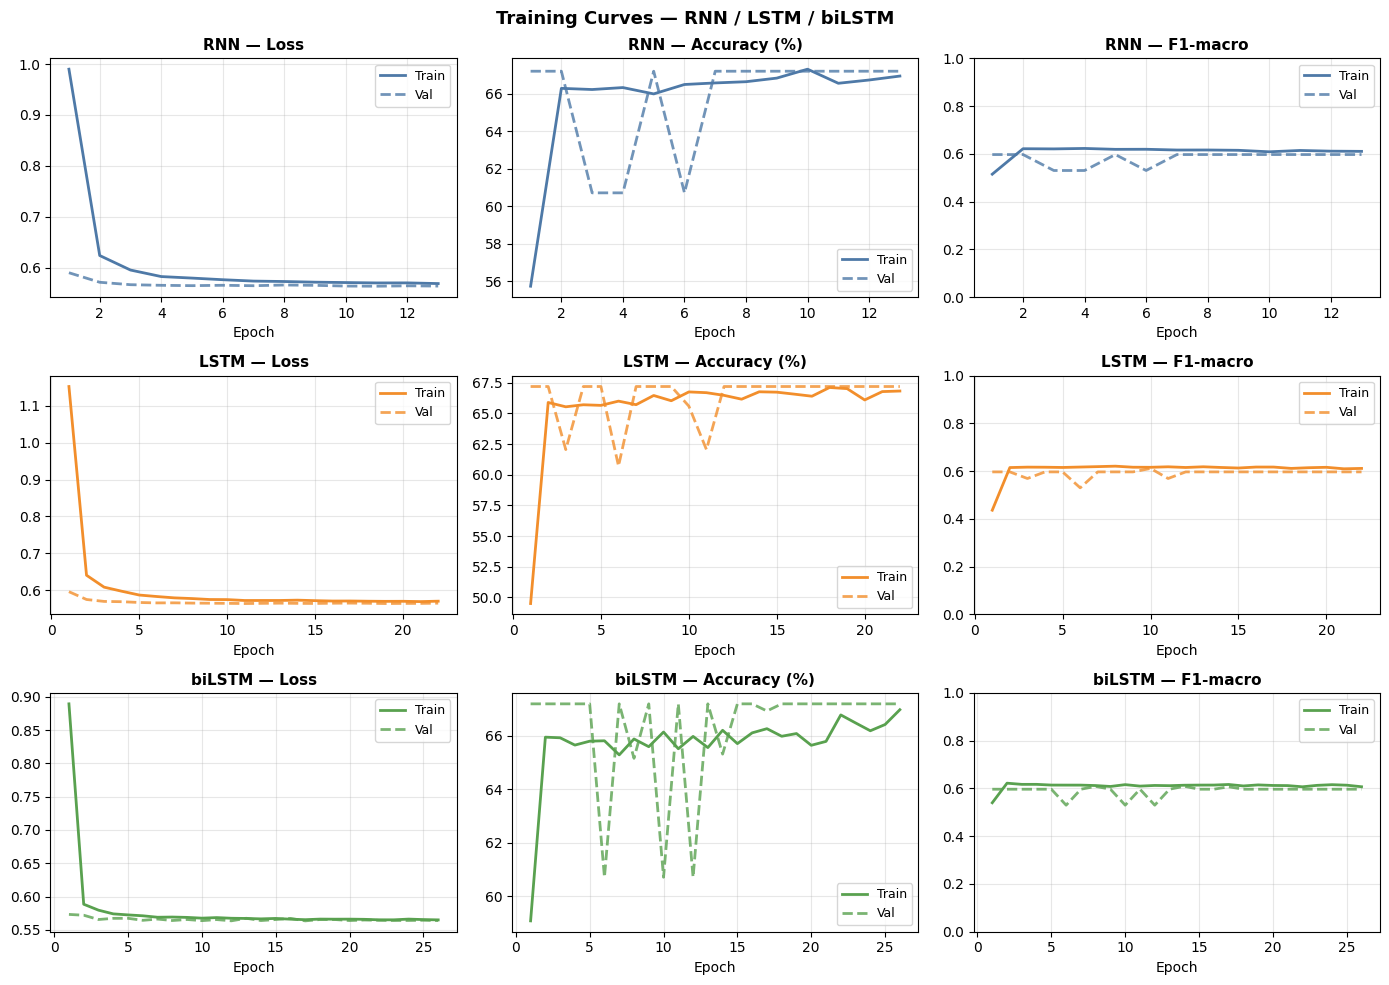

In [8]:
colors = {'RNN': '#4e79a7', 'LSTM': '#f28e2b', 'biLSTM': '#59a14f'}

fig, axes = plt.subplots(3, 3, figsize=(14, 10))

for row, m_type in enumerate(['RNN', 'LSTM', 'biLSTM']):
    h = all_results[m_type]['hist']
    c = colors[m_type]
    ep = range(1, len(h['train_loss']) + 1)

    for col, (train_key, val_key, title) in enumerate([
        ('train_loss',   'val_loss',    'Loss'),
        ('train_acc',    'val_acc',     'Accuracy (%)'),
        ('train_f1_mac', 'val_f1_mac',  'F1-macro'),
    ]):
        ax = axes[row, col]
        ax.plot(ep, h[train_key], color=c, lw=2,   label='Train')
        ax.plot(ep, h[val_key],   color=c, lw=2,   linestyle='--', label='Val', alpha=0.8)
        ax.set_title(f'{m_type} — {title}', fontweight='bold', fontsize=11)
        ax.set_xlabel('Epoch')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        if title == 'F1-macro':
            ax.set_ylim(0, 1)

plt.suptitle('Training Curves — RNN / LSTM / biLSTM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

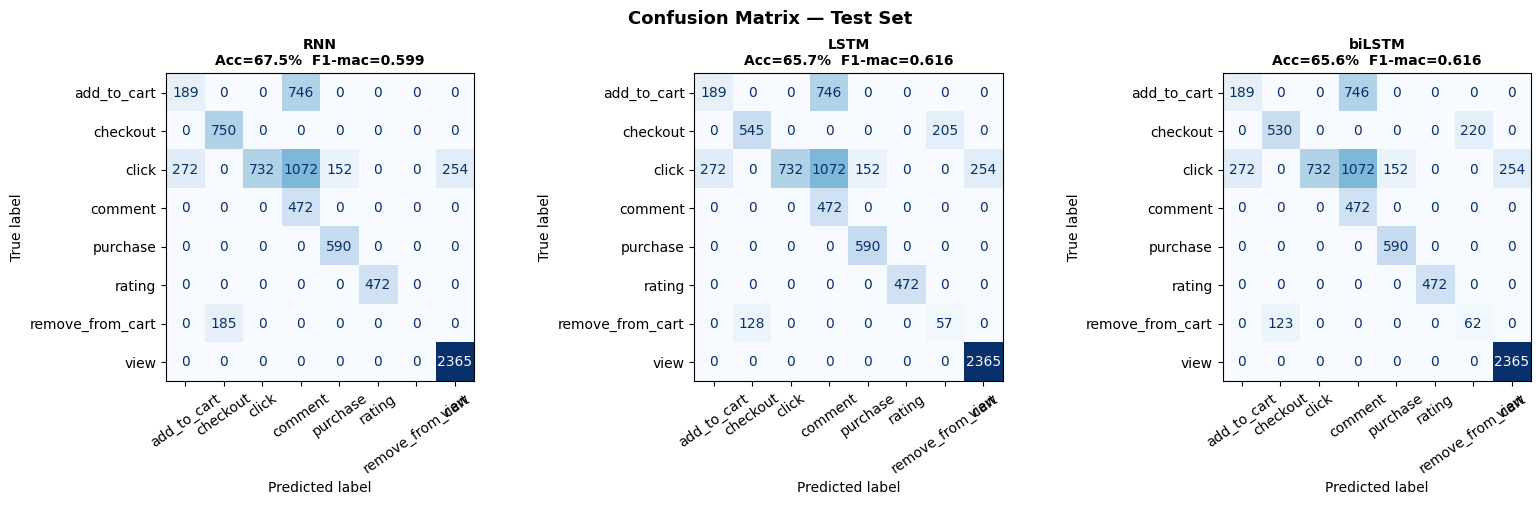

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (m_type, c) in zip(axes, colors.items()):
    r  = all_results[m_type]
    cm = confusion_matrix(r['test_true'], r['test_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', xticks_rotation=35)
    ax.set_title(
        f"{m_type}\nAcc={r['test_acc']:.1f}%  F1-mac={r['test_f1_mac']:.3f}",
        fontweight='bold', fontsize=10
    )

plt.suptitle('Confusion Matrix — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# ── Bảng so sánh ─────────────────────────────────────────────────
rows = []
for m_type, r in all_results.items():
    h = r['hist']
    rows.append({
        'Model'        : m_type,
        'Test Loss'    : round(r['test_loss'],    4),
        'Test Acc (%)'  : round(r['test_acc'],     2),
        'Test F1-macro' : round(r['test_f1_mac'],  4),
        'Test F1-wtd'   : round(r['test_f1_wtd'],  4),
        'Best Val F1'   : round(max(h['val_f1_mac']), 4),
        'Epochs'       : len(h['train_loss']),
    })

summary_df = pd.DataFrame(rows).sort_values('Test F1-macro', ascending=False).reset_index(drop=True)
print('=' * 72)
print('  KẾT QUẢ TRÊN TEST SET')
print('=' * 72)
print(summary_df.to_string(index=False))
print('=' * 72)

best_m = summary_df.iloc[0]['Model']
r_best = all_results[best_m]

print(f'\n=== Classification Report — {best_m} (Test Set) ===')
print(classification_report(
    r_best['test_true'], r_best['test_pred'],
    target_names=le.classes_, zero_division=0
))

  KẾT QUẢ TRÊN TEST SET
 Model  Test Loss  Test Acc (%)  Test F1-macro  Test F1-wtd  Best Val F1  Epochs
  LSTM     0.5645         65.71         0.6155       0.6552       0.6114      22
biLSTM     0.5643         65.59         0.6155       0.6545       0.6093      26
   RNN     0.5902         67.51         0.5991       0.6608       0.5969      13

=== Classification Report — LSTM (Test Set) ===
                  precision    recall  f1-score   support

     add_to_cart       0.41      0.20      0.27       935
        checkout       0.81      0.73      0.77       750
           click       1.00      0.29      0.46      2482
         comment       0.21      1.00      0.34       472
        purchase       0.80      1.00      0.89       590
          rating       1.00      1.00      1.00       472
remove_from_cart       0.22      0.31      0.26       185
            view       0.90      1.00      0.95      2365

        accuracy                           0.66      8251
       macro avg     

## 7. Đánh giá & Chọn model tốt nhất

In [11]:
r_rnn    = all_results['RNN']
r_lstm   = all_results['LSTM']
r_bilstm = all_results['biLSTM']
best_m   = summary_df.iloc[0]['Model']

eval_text = f"""
╔══════════════════════════════════════════════════════════════════╗
║  ĐÁNH GIÁ 3 MÔ HÌNH — NEXT ACTION PREDICTION                   ║
╠══════════════════════════════════════════════════════════════════╣

  📌 RNN  |  Acc={r_rnn['test_acc']:.1f}%  F1-mac={r_rnn['test_f1_mac']:.4f}  F1-wtd={r_rnn['test_f1_wtd']:.4f}

  📌 LSTM  |  Acc={r_lstm['test_acc']:.1f}%  F1-mac={r_lstm['test_f1_mac']:.4f}  F1-wtd={r_lstm['test_f1_wtd']:.4f}

  📌 biLSTM  |  Acc={r_bilstm['test_acc']:.1f}%  F1-mac={r_bilstm['test_f1_mac']:.4f}  F1-wtd={r_bilstm['test_f1_wtd']:.4f}

  🏆 MODEL TỐT NHẤT: {best_m}
     Acc={all_results[best_m]['test_acc']:.1f}%  F1-macro={all_results[best_m]['test_f1_mac']:.4f}

╚══════════════════════════════════════════════════════════════════╝
"""
print(eval_text)


╔══════════════════════════════════════════════════════════════════╗
║  ĐÁNH GIÁ 3 MÔ HÌNH — NEXT ACTION PREDICTION                   ║
╠══════════════════════════════════════════════════════════════════╣

  📌 RNN  |  Acc=67.5%  F1-mac=0.5991  F1-wtd=0.6608

  📌 LSTM  |  Acc=65.7%  F1-mac=0.6155  F1-wtd=0.6552

  📌 biLSTM  |  Acc=65.6%  F1-mac=0.6155  F1-wtd=0.6545

  🏆 MODEL TỐT NHẤT: LSTM
     Acc=65.7%  F1-macro=0.6155

╚══════════════════════════════════════════════════════════════════╝



In [12]:
# model_best = all_results[best_m]['model']
# torch.save({
#     'model_state': model_best.state_dict(),
#     'model_type' : best_m,
#     'le_classes' : list(le.classes_),
#     'vocab_size' : VOCAB_ACTION,
#     'num_classes': NUM_CLASSES,
#     'seq_len'    : SEQ_LEN,
# }, f'model_best_{best_m}.pth')

# print(f'✅ Saved model_best_{best_m}.pth')
# print(f'   - model_type : {best_m}')
# print(f'   - le_classes : {list(le.classes_)}')
# print(f'   - seq_len    : {SEQ_LEN}')
# print(f'   - num_classes: {NUM_CLASSES}')

In [13]:
# ── XUẤT CẢ 3 MODEL RA OUTPUT KAGGLE ĐỂ ADMIN TÙY CHỌN ─────────────────

for m_type in ['RNN', 'LSTM', 'biLSTM']:
    # Lấy model tương ứng từ kết quả dict
    model_to_save = all_results[m_type]['model']
    
    # Đóng gói state_dict và toàn bộ metadata cần thiết
    checkpoint = {
        'model_state': model_to_save.state_dict(),
        'model_type' : m_type,
        'le_classes' : list(le.classes_),
        'vocab_size' : VOCAB_ACTION,
        'num_classes': NUM_CLASSES,
        'seq_len'    : SEQ_LEN,
        'embed_dim'  : 32,  # Lưu thêm các hyperparameter cấu hình mạng
        'hidden_dim' : 64,
        'n_layers'   : 2,
        'dropout'    : 0.3
    }
    
    # Lưu file với tên động tương ứng với từng mạng
    file_name = f'model_best_{m_type}.pth'
    torch.save(checkpoint, file_name)
    
    print(f'✅ Saved {file_name}')
    print(f'   - model_type : {m_type}')
    print(f'   - seq_len    : {SEQ_LEN}')
    print(f'   - num_classes: {NUM_CLASSES}')
    print('-' * 40)

✅ Saved model_best_RNN.pth
   - model_type : RNN
   - seq_len    : 5
   - num_classes: 8
----------------------------------------
✅ Saved model_best_LSTM.pth
   - model_type : LSTM
   - seq_len    : 5
   - num_classes: 8
----------------------------------------
✅ Saved model_best_biLSTM.pth
   - model_type : biLSTM
   - seq_len    : 5
   - num_classes: 8
----------------------------------------


In [14]:
# ── Cài thư viện ──
!pip install neo4j -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 11.9 MB/s eta 0:00:00


In [15]:
from neo4j import GraphDatabase
from kaggle_secrets import UserSecretsClient

secrets  = UserSecretsClient()
URI      = secrets.get_secret("NEO4J_URI")
PASSWORD = secrets.get_secret("NEO4J_PASSWORD")
USERNAME = secrets.get_secret("NEO4J_USERNAME")

driver = GraphDatabase.driver(URI, auth=(USERNAME, PASSWORD))
driver.verify_connectivity()
print("✅ Kết nối Aura thành công!")

✅ Kết nối Aura thành công!


In [16]:
# ── Schema: CONSTRAINTS + INDEXES ──────────────────────────────────
def setup_schema(driver):
    """Tạo constraints và indexes cho graph"""
    with driver.session() as session:
        # Users
        session.run("CREATE CONSTRAINT IF NOT EXISTS FOR (u:User) REQUIRE u.user_id IS UNIQUE")
        session.run("CREATE INDEX IF NOT EXISTS FOR (u:User) ON (u.user_id)")
        
        # Products
        session.run("CREATE CONSTRAINT IF NOT EXISTS FOR (p:Product) REQUIRE p.product_id IS UNIQUE")
        session.run("CREATE INDEX IF NOT EXISTS FOR (p:Product) ON (p.product_id)")
        
        # Actions (types)
        session.run("CREATE CONSTRAINT IF NOT EXISTS FOR (a:Action) REQUIRE a.name IS UNIQUE")
        session.run("CREATE INDEX IF NOT EXISTS FOR (a:Action) ON (a.name)")
        
    print("✅ Schema (constraints + indexes) đã tạo!")

setup_schema(driver)

✅ Schema (constraints + indexes) đã tạo!


In [17]:
# ── Tạo nút Action (types) ──────────────────────────────────────────
def create_action_nodes(driver):
    """Tạo nodes cho 8 loại action"""
    with driver.session() as session:
        # Delete existing actions
        session.run("MATCH (a:Action) DETACH DELETE a")
        
        for idx, action_name in enumerate(le.classes_, 1):
            session.run("""
                CREATE (a:Action {name: $name, id: $id})
            """, name=action_name, id=idx)
    
    print(f"✅ Tạo {len(le.classes_)} Action nodes: {list(le.classes_)}")

create_action_nodes(driver)

✅ Tạo 8 Action nodes: ['add_to_cart', 'checkout', 'click', 'comment', 'purchase', 'rating', 'remove_from_cart', 'view']


In [18]:
# ── Tạo nút User + Product ────────────────────────────────────────────
def create_user_product_nodes(driver, df):
    """Tạo User và Product nodes từ dataframe"""
    with driver.session() as session:
        # Delete existing nodes (keep Actions)
        session.run("MATCH (u:User) DETACH DELETE u")
        session.run("MATCH (p:Product) DETACH DELETE p")
        
        # Users
        unique_users = df['user_id'].unique()
        for user_id in unique_users:
            session.run("""
                CREATE (u:User {user_id: $uid})
            """, uid=str(user_id))
        
        # Products
        unique_products = df['product_id'].unique()
        for product_id in unique_products:
            session.run("""
                CREATE (p:Product {product_id: $pid})
            """, pid=str(product_id))
    
    print(f"✅ Tạo {len(unique_users)} User nodes")
    print(f"✅ Tạo {len(unique_products)} Product nodes")

create_user_product_nodes(driver, df)

✅ Tạo 1000 User nodes
✅ Tạo 1000 Product nodes


In [19]:
# ── Tạo Relationships (USER -[PERFORMS]-> ACTION -[ON]-> PRODUCT) ──
def create_event_relationships(driver, df):
    """Tạo relationships từ events: User -[PERFORMS]-> Action -[ON]-> Product"""
    with driver.session() as session:
        # Delete existing relationships (keep nodes)
        session.run("MATCH ()-[r:PERFORMS]-() DELETE r")
        session.run("MATCH ()-[r:ON]-() DELETE r")
        
        # Batch insert events
        batch_size = 1000
        total = len(df)
        
        for i in range(0, total, batch_size):
            batch = df.iloc[i:i+batch_size]
            
            for _, row in batch.iterrows():
                session.run("""
                    MATCH (u:User {user_id: $uid})
                    MATCH (a:Action {name: $action})
                    MATCH (p:Product {product_id: $pid})
                    CREATE (u)-[r:PERFORMS {timestamp: $ts}]->(a)-[r2:ON]->(p)
                """,
                uid=str(row['user_id']),
                action=row['action'],
                pid=str(row['product_id']),
                ts=row['timestamp'].isoformat()
                )
            
            if (i + batch_size) % 2000 == 0 or (i + batch_size) >= total:
                print(f"  ✓ Processed {min(i + batch_size, total)}/{total} events")
    
    print(f"✅ Tạo {len(df)} event relationships (USER-[PERFORMS]->ACTION-[ON]->PRODUCT)")

create_event_relationships(driver, df)

  ✓ Processed 2000/55997 events
  ✓ Processed 4000/55997 events
  ✓ Processed 6000/55997 events
  ✓ Processed 8000/55997 events
  ✓ Processed 10000/55997 events
  ✓ Processed 12000/55997 events
  ✓ Processed 14000/55997 events
  ✓ Processed 16000/55997 events
  ✓ Processed 18000/55997 events
  ✓ Processed 20000/55997 events
  ✓ Processed 22000/55997 events
  ✓ Processed 24000/55997 events
  ✓ Processed 26000/55997 events
  ✓ Processed 28000/55997 events
  ✓ Processed 30000/55997 events
  ✓ Processed 32000/55997 events
  ✓ Processed 34000/55997 events
  ✓ Processed 36000/55997 events
  ✓ Processed 38000/55997 events
  ✓ Processed 40000/55997 events
  ✓ Processed 42000/55997 events
  ✓ Processed 44000/55997 events
  ✓ Processed 46000/55997 events
  ✓ Processed 48000/55997 events
  ✓ Processed 50000/55997 events
  ✓ Processed 52000/55997 events
  ✓ Processed 54000/55997 events
  ✓ Processed 55997/55997 events
✅ Tạo 55997 event relationships (USER-[PERFORMS]->ACTION-[ON]->PRODUCT)


In [20]:
# ── Tạo Action Transition Pattern (ACTION -[TRANSITIONS_TO]-> ACTION) ──
def create_action_transitions(driver, df):
    """Tạo transition patterns: ACTION -[TRANSITIONS_TO {count, prob}]-> ACTION"""
    with driver.session() as session:
        # Clear existing transitions
        session.run("MATCH (a1:Action)-[r:TRANSITIONS_TO]-(a2:Action) DELETE r")
        
        # Tính transition frequency cho mỗi user
        transitions = {}
        
        for uid, group in df.groupby('user_id'):
            group = group.sort_values('timestamp').reset_index(drop=True)
            
            for i in range(len(group) - 1):
                curr_action = group.iloc[i]['action']
                next_action = group.iloc[i+1]['action']
                key = (curr_action, next_action)
                transitions[key] = transitions.get(key, 0) + 1
        
        # Tính xác suất và tạo relationships
        total_trans = sum(transitions.values())
        
        for (curr, next_a), count in transitions.items():
            prob = count / total_trans
            session.run("""
                MATCH (a1:Action {name: $curr})
                MATCH (a2:Action {name: $next})
                CREATE (a1)-[r:TRANSITIONS_TO {count: $cnt, probability: $prob}]->(a2)
            """,
            curr=curr,
            next=next_a,
            cnt=count,
            prob=round(prob, 4)
            )
        
    print(f"✅ Tạo {len(transitions)} action transition patterns")
    print(f"   Ví dụ:")
    for (curr, next_a), count in sorted(transitions.items(), 
                                        key=lambda x: x[1], reverse=True)[:5]:
        print(f"     {curr:20s} → {next_a:20s}: {count:4d} times")

create_action_transitions(driver, df)

✅ Tạo 14 action transition patterns
   Ví dụ:
     click                → view                : 15738 times
     view                 → click               : 7145 times
     view                 → add_to_cart         : 4987 times
     add_to_cart          → checkout            : 4985 times
     checkout             → purchase            : 3931 times


In [21]:
# ── Truy vấn KB_Graph: Thống kê & Pattern ───────────────────────────
def query_kb_stats(driver):
    """Lấy thống kê cơ bản của knowledge base"""
    with driver.session() as session:
        # Node counts
        node_counts = {}
        for label in ['User', 'Product', 'Action']:
            result = session.run(f"MATCH (n:{label}) RETURN count(n) as cnt")
            node_counts[label] = result.single()['cnt']
        
        # Relationship counts
        rel_counts = {}
        for rel_type in ['PERFORMS', 'ON', 'TRANSITIONS_TO']:
            result = session.run(f"MATCH ()-[r:{rel_type}]->() RETURN count(r) as cnt")
            rel_counts[rel_type] = result.single()['cnt']
        
    stats_text = f"""
╔════════════════════════════════════════════════════════════════════╗
║           KNOWLEDGE BASE GRAPH — STATISTICS                  ║
╠════════════════════════════════════════════════════════════════════╣
║                                                               ║
║  📊 NODES:                                                    ║
║     • Users:    {node_counts['User']:6d}                      ║
║     • Products: {node_counts['Product']:6d}                   ║
║     • Actions:  {node_counts['Action']:6d}                    ║
║                                                                ║
║  🔗 RELATIONSHIPS:                                            ║
║     • USER -[PERFORMS]-> ACTION:  {rel_counts['PERFORMS']:6d} ║
║     • ACTION -[ON]-> PRODUCT:      {rel_counts['ON']:6d}      ║
║     • ACTION -[TRANSITIONS_TO]->:  {rel_counts['TRANSITIONS_TO']:6d} ║
║                                                               ║
╚════════════════════════════════════════════════════════════════════╝
    """
    print(stats_text)
    return node_counts, rel_counts

node_counts, rel_counts = query_kb_stats(driver)


╔════════════════════════════════════════════════════════════════════╗
║           KNOWLEDGE BASE GRAPH — STATISTICS                  ║
╠════════════════════════════════════════════════════════════════════╣
║                                                               ║
║  📊 NODES:                                                    ║
║     • Users:      1000                      ║
║     • Products:   1000                   ║
║     • Actions:       8                    ║
║                                                                ║
║  🔗 RELATIONSHIPS:                                            ║
║     • USER -[PERFORMS]-> ACTION:   55997 ║
║     • ACTION -[ON]-> PRODUCT:       55997      ║
║     • ACTION -[TRANSITIONS_TO]->:      14 ║
║                                                               ║
╚════════════════════════════════════════════════════════════════════╝
    


In [22]:
# ── Ví dụ Query 1: Top Transition Patterns ─────────────────────────
def query_top_transitions(driver, top_n=10):
    """Lấy top N transition patterns theo xác suất"""
    with driver.session() as session:
        result = session.run("""
            MATCH (a1:Action)-[r:TRANSITIONS_TO]->(a2:Action)
            RETURN a1.name as from_action, a2.name as to_action, 
                   r.count as count, r.probability as prob
            ORDER BY prob DESC
            LIMIT $limit
        """, limit=top_n)
        
        results = result.data()
    
    print(f"\n{'='*70}")
    print(f"  TOP {top_n} ACTION TRANSITION PATTERNS")
    print(f"{'='*70}")
    print(f"  {'From':20s} → {'To':20s} | {'Count':6s} | {'Prob':8s}")
    print(f"{'-'*70}")
    
    for row in results:
        print(f"  {row['from_action']:20s} → {row['to_action']:20s} | "
              f"{row['count']:6d} | {row['prob']:7.4f}")
    
    print(f"{'='*70}\n")

query_top_transitions(driver, top_n=10)


  TOP 10 ACTION TRANSITION PATTERNS
  From                 → To                   | Count  | Prob    
----------------------------------------------------------------------
  click                → view                 |  15738 |  0.2862
  view                 → click                |   7145 |  0.1299
  view                 → add_to_cart          |   4987 |  0.0907
  add_to_cart          → checkout             |   4985 |  0.0906
  checkout             → purchase             |   3931 |  0.0715
  purchase             → click                |   3701 |  0.0673
  comment              → rating               |   3160 |  0.0575
  view                 → comment              |   3160 |  0.0575
  rating               → click                |   1816 |  0.0330
  click                → click                |   1713 |  0.0311



In [23]:
# ── Ví dụ Query 2: Lấy Action Sequence của một User ──────────────
def query_user_sequence(driver, user_id):
    """Lấy chuỗi action của một user theo thứ tự thời gian"""
    with driver.session() as session:
        result = session.run("""
            MATCH (u:User {user_id: $uid})-[r:PERFORMS]->(a:Action)-[r2:ON]->(p:Product)
            RETURN a.name as action, p.product_id as product_id, r.timestamp as timestamp
            ORDER BY r.timestamp
        """, uid=str(user_id))
        
        results = result.data()
    
    if not results:
        print(f"❌ User {user_id} không có dữ liệu")
        return
    
    print(f"\n{'='*70}")
    print(f"  USER {user_id} — ACTION SEQUENCE ({len(results)} events)")
    print(f"{'='*70}")
    print(f"  {'#':3s} | {'Action':20s} | {'Product':10s} | {'Timestamp':19s}")
    print(f"{'-'*70}")
    
    for i, row in enumerate(results[:20], 1):  # Show first 20
        ts = row['timestamp'][:19] if isinstance(row['timestamp'], str) else str(row['timestamp'])[:19]
        print(f"  {i:3d} | {row['action']:20s} | {row['product_id']:10s} | {ts}")
    
    if len(results) > 20:
        print(f"  ... and {len(results) - 20} more")
    print(f"{'='*70}\n")

# Lấy user_id đầu tiên để demo
sample_user = df['user_id'].iloc[0]
query_user_sequence(driver, sample_user)


  USER 1 — ACTION SEQUENCE (609786 events)
  #   | Action               | Product    | Timestamp          
----------------------------------------------------------------------
    1 | click                | 369        | 2026-04-09T18:09:36
    2 | click                | 369        | 2026-04-09T18:09:36
    3 | click                | 369        | 2026-04-09T18:09:36
    4 | click                | 369        | 2026-04-09T18:09:36
    5 | click                | 369        | 2026-04-09T18:09:36
    6 | click                | 369        | 2026-04-09T18:09:36
    7 | click                | 369        | 2026-04-09T18:09:36
    8 | click                | 369        | 2026-04-09T18:09:36
    9 | click                | 369        | 2026-04-09T18:09:36
   10 | click                | 369        | 2026-04-09T18:09:36
   11 | click                | 369        | 2026-04-09T18:09:36
   12 | click                | 369        | 2026-04-09T18:09:36
   13 | click                | 369        | 2026-04-0

In [24]:
# ── Ví dụ Query 3: Recommend Next Action từ KB_Graph ────────────────
def recommend_next_action(driver, current_action, top_n=5):
    """
    Dự đoán next action dựa trên transition patterns trong graph
    Input: current_action (string)
    Output: Top N most likely next actions + probabilities
    """
    with driver.session() as session:
        result = session.run("""
            MATCH (a1:Action {name: $curr})-[r:TRANSITIONS_TO]->(a2:Action)
            RETURN a2.name as next_action, r.count as count, r.probability as prob
            ORDER BY prob DESC
            LIMIT $limit
        """, curr=current_action, limit=top_n)
        
        results = result.data()
    
    if not results:
        print(f"❌ Không tìm thấy transition sau '{current_action}'")
        return None
    
    print(f"\n{'='*70}")
    print(f"  RECOMMEND NEXT ACTION — After '{current_action}'")
    print(f"{'='*70}")
    print(f"  {'Rank':4s} | {'Next Action':20s} | {'Count':7s} | {'Prob':8s}")
    print(f"{'-'*70}")
    
    for i, row in enumerate(results, 1):
        print(f"  {i:4d}. {row['next_action']:20s} | {row['count']:7d} | {row['prob']:7.4f}")
    
    print(f"{'='*70}\n")
    return results

# Demo
sample_action = df['action'].iloc[0]
recommend_next_action(driver, sample_action, top_n=8)


  RECOMMEND NEXT ACTION — After 'click'
  Rank | Next Action          | Count   | Prob    
----------------------------------------------------------------------
     1. view                 |   15738 |  0.2862
     2. click                |    1713 |  0.0311



[{'next_action': 'view', 'count': 15738, 'prob': 0.2862},
 {'next_action': 'click', 'count': 1713, 'prob': 0.0311}]

In [25]:
# ── Tóm tắt KB_Graph Structure ───────────────────────────────────────
summary = """
╔════════════════════════════════════════════════════════════════════════════╗
║                 📊 KNOWLEDGE BASE GRAPH — ARCHITECTURE              ║
╠════════════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  🔷 NODES (3 types):                                                ║
║     • User       → user_id                                           ║
║     • Product    → product_id                                        ║
║     • Action     → name (8 types: click, view, add_to_cart, ...)     ║
║                                                                      ║
║  🔗 RELATIONSHIPS:                                                   ║
║     1. USER -[PERFORMS]-> ACTION                                     ║
║        └─ timestamp property (khi user thực hiện action)             ║
║                                                                      ║
║     2. ACTION -[ON]-> PRODUCT                                        ║
║        └─ action được thực hiện trên product nào                     ║
║                                                                      ║
║     3. ACTION -[TRANSITIONS_TO]-> ACTION                             ║
║        └─ properties: count, probability                             ║
║        └─ action A thường dẫn đến action B bao nhiêu lần             ║
║                                                                      ║
╠════════════════════════════════════════════════════════════════════════════╣
║  💡 USE CASES:                                                             ║
║                                                                            ║
║  1️⃣  PATTERN MINING                                                        ║
║      → Tìm action sequences thường xuyên (via TRANSITIONS_TO)             ║
║      → Ví dụ: view → click → add_to_cart → checkout                       ║
║                                                                            ║
║  2️⃣  USER JOURNEY ANALYSIS                                                ║
║      → Lấy chuỗi action của user theo thứ tự (PERFORMS + timestamp)      ║
║      → Tính toán session path, funnel analysis                            ║
║                                                                            ║
║  3️⃣  NEXT ACTION PREDICTION                                               ║
║      → Dựa trên TRANSITIONS_TO probabilities                              ║
║      → Recommend next action khi biết current action                      ║
║      → Input cho recommendation engine                                    ║
║                                                                            ║
║  4️⃣  PRODUCT AFFINITY                                                     ║
║      → Tìm products nào thường xuất hiện cùng nhau                        ║
║      → Via: ACTION -[ON]-> PRODUCT pattern                                ║
║                                                                            ║
║  5️⃣  CONTENT RECOMMENDATION                                               ║
║      → Kết hợp KB_Graph + LSTM model predictions                          ║
║      → Gợi ý action tiếp theo → recommend products                        ║
║                                                                            ║
╚════════════════════════════════════════════════════════════════════════════╝
"""
print(summary)

print("✅ Knowledge Base Graph (KB_Graph) đã xây dựng hoàn chỉnh!")
print("\n   Bây giờ bạn có thể:")
print("   • Phân tích user behavior patterns")
print("   • Dự đoán next action (kết hợp KB_Graph + Deep Learning model)")
print("   • Xây dựng recommendation system")
print("   • Analyze product affinity & cross-sell opportunities")


╔════════════════════════════════════════════════════════════════════════════╗
║                 📊 KNOWLEDGE BASE GRAPH — ARCHITECTURE              ║
╠════════════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  🔷 NODES (3 types):                                                ║
║     • User       → user_id                                           ║
║     • Product    → product_id                                        ║
║     • Action     → name (8 types: click, view, add_to_cart, ...)     ║
║                                                                      ║
║  🔗 RELATIONSHIPS:                                                   ║
║     1. USER -[PERFORMS]-> ACTION                                     ║
║        └─ timestamp property (khi user thực hiện action)             ║
║                                                                      ║
║     2. ACTION -[ON]-> PRODUCT            

In [26]:
!pip install --upgrade langchain langchain-community langchain-openai neo4j

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.2/121.2 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.4/236.4 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.2/56.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 2.9 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: openai
    Found existing in

In [27]:
!pip install -U langchain langchain-community langchain-google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.8/68.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 822.5/822.5 kB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.1/246.1 kB 18.0 MB/s eta 0:00:00
  Attempting uninstall: google-auth
    Found existing installation: google-auth 2.47.0
    Uninstalling google-auth-2.47.0:
      Successfully uninstalled google-auth-2.47.0
  Attempting uninstall: google-genai
    Found existing installation: google-genai 1.64.0
    Uninstalling google-genai-1.64.0:
      Successfully uninstalled google-genai-1.64.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storag

In [28]:
with driver.session() as session:
    # Truy vấn kiểm tra tổng số nút
    result = session.run("MATCH (n) RETURN count(n) AS count")
    print(f"Tổng số nút trên đồ thị: {result.single()['count']}")

Tổng số nút trên đồ thị: 2027


In [29]:
with driver.session() as session:
    result = session.run("SHOW DATABASES")
    for record in result:
        print(f"Tên Database của bạn là: {record['name']}")

Tên Database của bạn là: 7b014686
Tên Database của bạn là: system
Tên Database của bạn là: system
Tên Database của bạn là: system


In [30]:
import os
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_community.graphs import Neo4jGraph
try:
    from langchain.chains import GraphCypherQAChain
except ImportError:
    from langchain_community.chains.graph_qa.cypher import GraphCypherQAChain

# 1. Cấu hình API Key từ AI Studio
os.environ["GOOGLE_API_KEY"] = secrets.get_secret("GOOGLE_AI_STUDIO_API_KEY")
DATABASE = secrets.get_secret("NEO4J_DATABASE")

graph = Neo4jGraph(
    url=URI, 
    username=USERNAME, 
    password=PASSWORD,
    database=DATABASE,
    enhanced_schema=True 
)

graph.refresh_schema()




/tmp/ipykernel_23/2031354838.py:13: LangChainDeprecationWarning: The class `Neo4jGraph` was deprecated in LangChain 0.3.8 and will be removed in 1.0. An updated version of the class exists in the `langchain-neo4j package and should be used instead. To use it run `pip install -U `langchain-neo4j` and import as `from `langchain_neo4j import Neo4jGraph``.
  graph = Neo4jGraph(
Received notification from DBMS server: <GqlStatusObject gql_status='01N00', status_description='warn: feature deprecated. `config` used by the procedure `apoc.meta.graphSample` is deprecated.', position=<SummaryInputPosition line=1, column=1, offset=0>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 0, 'line': 1, 'column': 1}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA':

In [31]:

class SimpleGraphChat:
    def __init__(self, uri, user, password, database):
        self._driver = GraphDatabase.driver(uri, auth=(user, password))
        self._database = database

    def close(self):
        self._driver.close()

    def query_graph(self, cypher, params):
        with self._driver.session(database=self._database) as session:
            result = session.run(cypher, params)
            return [record.data() for record in result]

# Khởi tạo Client
client = SimpleGraphChat(URI, USERNAME, PASSWORD, DATABASE)

def chat_bot_en(user_input, user_id):
    text = user_input.lower().strip()
    uid = int(user_id) # Chuyển về int vì data user_id của bạn là số

    if "bought" in text or "purchased" in text or "history" in text:
        data = client.query_graph(
            """
            MATCH (u:User {id: $uid})-[r:PURCHASED]->(p:Product)
            RETURN p.name AS product_name, r.timestamp AS timestamp
            ORDER BY timestamp DESC LIMIT 5
            """,
            {"uid": uid}
        )
        if not data: 
            return f"User {uid} hasn't purchased any products yet."
        
        res = f"Purchase history for User {uid}:\n"
        for item in data:
            res += f"- {item['product_name']} (at {item['timestamp']})\n"
        return res

    # CASE 2: Smart Recommendations (Based on Click/View/Add to Cart)
    if "suggest" in text or "recommend" in text or "should i buy" in text:
        data = client.query_graph(
            """
            MATCH (u:User {id: $uid})-[r:CLICKED|VIEWED|ADDED_TO_CART]->(p:Product)
            WITH p, count(r) AS interaction_score
            RETURN p.name AS product_name, interaction_score
            ORDER BY interaction_score DESC LIMIT 3
            """,
            {"uid": uid}
        )
        if not data: 
            return "No recent activity found. Explore our latest products!"
        
        res = "Based on your activity, we recommend:\n"
        for item in data:
            res += f"- {item['product_name']} (Relevance Score: {item['interaction_score']})\n"
        return res

    return "I'm sorry, I can only help with your purchase history or product recommendations."

# --- TEST DEMO FOR YOUR REPORT (Câu 2c & 2d) ---
uid_test = 10 
print("User Question: What have I bought?")
print("Bot Response:", chat_bot_en("What have I bought?", uid_test))

print("\n-------------------\n")

print("User Question: Any recommendations for me?")
print("Bot Response:", chat_bot_en("Any recommendations for me?", uid_test))

User Question: What have I bought?
Bot Response: User 10 hasn't purchased any products yet.

-------------------

User Question: Any recommendations for me?
Bot Response: No recent activity found. Explore our latest products!
